# Real-Time Crisis Detection System
## Notebook 07 — Sanity Checks & Plots
**Goal:** Generate final analytical plots, maps, and dashboard-ready datasets.

In [1]:
import os, sys, warnings; warnings.filterwarnings('ignore')
IN_COLAB='google.colab' in sys.modules; IN_KAGGLE='KAGGLE_URL_BASE' in os.environ
if IN_COLAB:
    from google.colab import drive; drive.mount('/content/drive')
    PROJECT_DIR='/content/drive/MyDrive/10Academy/crisis-detection-system'
elif IN_KAGGLE: PROJECT_DIR='/kaggle/working/crisis-detection-system'
else: PROJECT_DIR=os.path.abspath('..')
DATA_PROCESSED=f'{PROJECT_DIR}/data/processed'
OUTPUTS_DIR=f'{PROJECT_DIR}/outputs'
os.makedirs(f'{OUTPUTS_DIR}/figures', exist_ok=True)
os.makedirs(f'{OUTPUTS_DIR}/maps', exist_ok=True)
print(f' Ready. Project: {PROJECT_DIR}')

Mounted at /content/drive
✅ Ready. Project: /content/drive/MyDrive/10Academy/crisis-detection-system


In [2]:
!pip install -q folium geopandas matplotlib seaborn wordcloud

In [3]:
# Load Final Data
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster
from wordcloud import WordCloud

master_df = pd.read_csv(f'{DATA_PROCESSED}/master_events.csv')
events_df = pd.read_csv(f'{DATA_PROCESSED}/clustered_events.csv')

master_df['ts_dt'] = pd.to_datetime(master_df['timestamp_event_utc']).dt.tz_convert(None)
events_df['ts_dt'] = pd.to_datetime(events_df['event_timestamp']).dt.tz_localize(None)

print(f' Loaded {len(events_df)} Canonical Events, and {len(master_df)} raw posts.')

✅ Loaded 18 Canonical Events, and 75 raw posts.


In [4]:
# Interactive Crisis Map (Folium)
def create_crisis_map(df, out_path):
# Base map centered on Indonesia
    m = folium.Map(location=[-2.5489, 118.0149], zoom_start=5, tiles='CartoDB positron')

# Colors per event type
    colors = {
        'earthquake': 'red', 'flood': 'blue', 'fire': 'orange',
        'accident': 'black', 'violence': 'purple', 'storm': 'darkblue',
        'other': 'gray'
    }

    mc = MarkerCluster()

    mapped_count = 0
    for idx, row in df.iterrows():
        lat, lon = row.get('event_lat'), row.get('event_lon')
        if pd.isna(lat) or pd.isna(lon):
            continue

        evt_type = str(row.get('event_type', 'other'))
        color = colors.get(evt_type, 'gray')

        popup_text = f"""
        <b>Type:</b> {evt_type.title()}<br>
        <b>Time:</b> {row.get('event_timestamp')}<br>
        <b>Credibility:</b> {row.get('cluster_credibility', 0):.2f}<br>
        <b>Summary:</b> {str(row.get('llm_summary', ''))[:100]}...
        """

        folium.CircleMarker(
            location=[lat, lon],
            radius=8 + min(row.get('cluster_size', 1), 10),
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.7,
            popup=folium.Popup(popup_text, max_width=300)
        ).add_to(mc)
        mapped_count += 1

    mc.add_to(m)
    m.save(out_path)
    print(f' Map saved to {out_path} with {mapped_count} events.')
    return m

crisis_map = create_crisis_map(events_df, f'{OUTPUTS_DIR}/maps/interactive_crisis_map.html')
crisis_map

✅ Map saved to /content/drive/MyDrive/10Academy/crisis-detection-system/outputs/maps/interactive_crisis_map.html with 18 events.


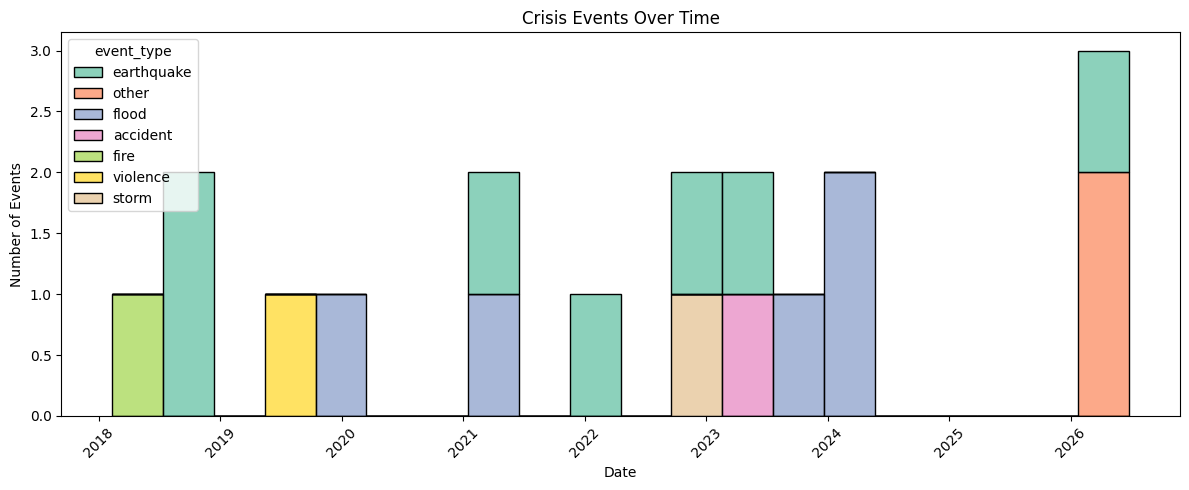

In [5]:
# Temporal Event Distribution
plt.figure(figsize=(12, 5))
sns.histplot(data=events_df, x='ts_dt', hue='event_type', multiple='stack', bins=20, palette='Set2')
plt.title('Crisis Events Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/figures/events_over_time.png', dpi=150)
plt.show()

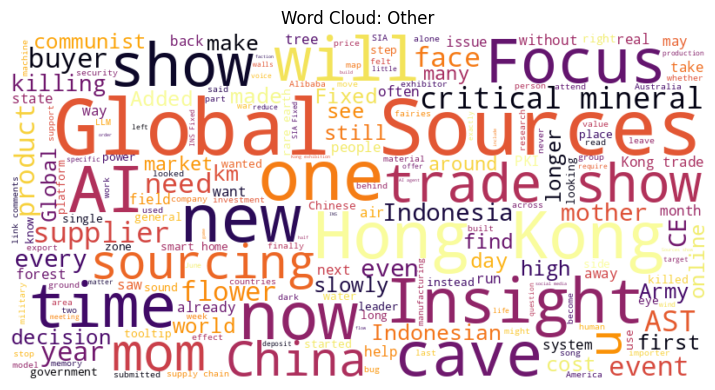

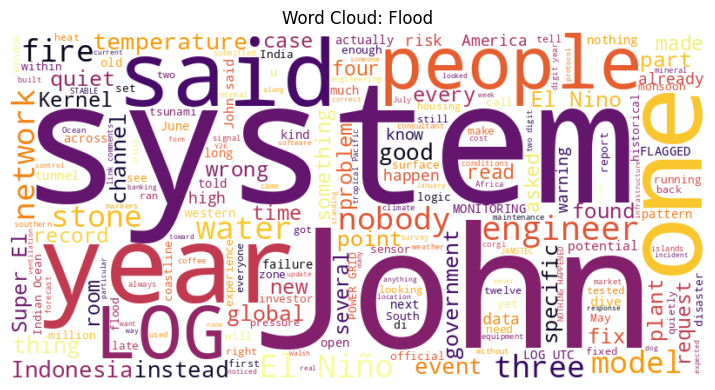

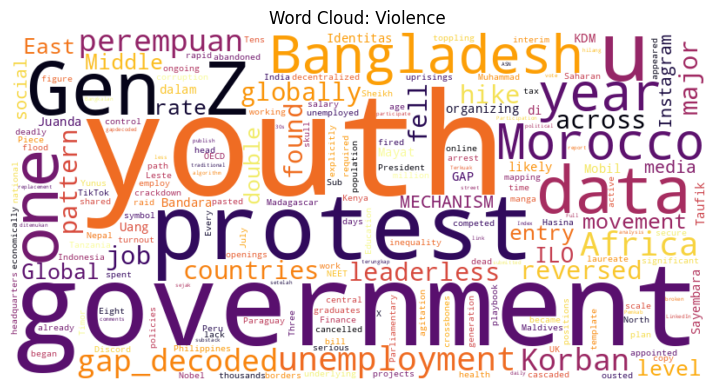

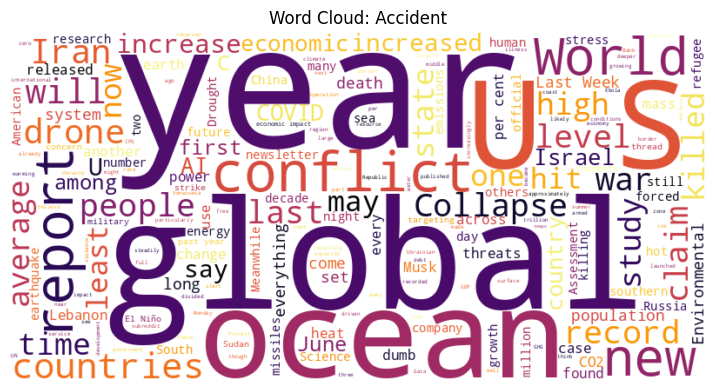

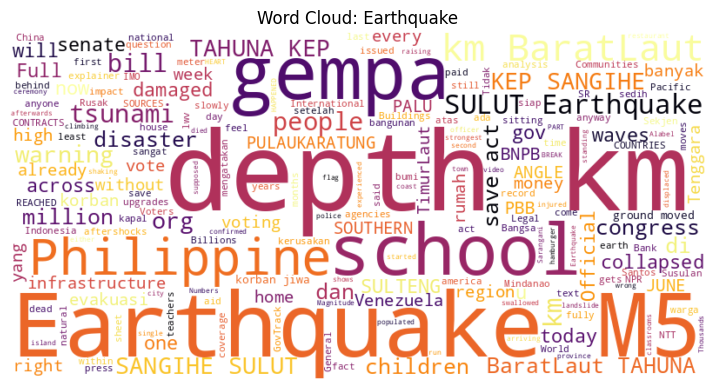

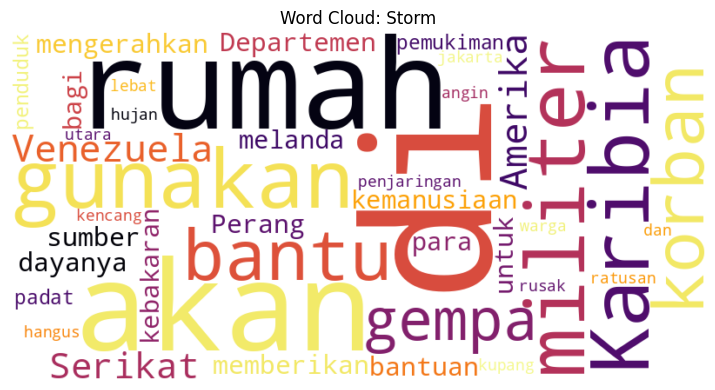

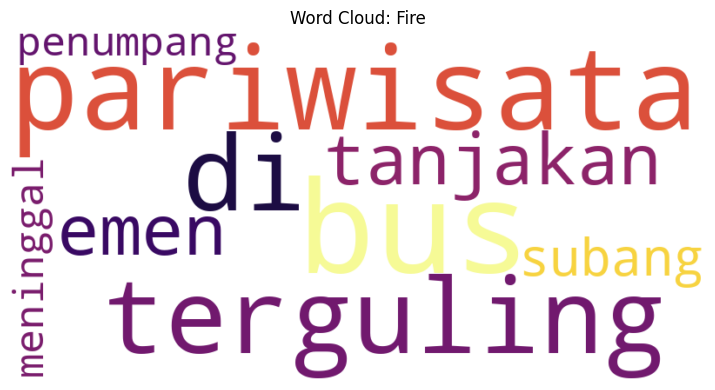

In [6]:
# Word Clouds per Event Type
def generate_wordcloud(df, event_type):
    text = " ".join(df[df['predicted_class'] == event_type]['text_cleaned'].dropna().astype(str))
    if len(text.strip()) == 0:
        return

    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='inferno').generate(text)

    plt.figure(figsize=(8, 4))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud: {event_type.title()}')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f'{OUTPUTS_DIR}/figures/wordcloud_{event_type}.png', dpi=150)
    plt.show()

for etype in master_df['predicted_class'].dropna().unique():
    generate_wordcloud(master_df, etype)

In [7]:
# Data Summary & Export for Dashboard
print('=== FINAL DASHBOARD DATASET STATS ===')
print(f'Total Events: {len(events_df)}')
print(f'Total Posts Tracked: {len(master_df)}')
print('\nEvents by Type:')
print(events_df['event_type'].value_counts())
print('\nEvents by Severity (if derived):')
print(events_df.get('event_severity', pd.Series(['unknown']*len(events_df))).value_counts())

# Export minimal geoJSON for web dashboards
import json
geojson = {
    "type": "FeatureCollection",
    "features": []
}
for idx, row in events_df.iterrows():
    if pd.isna(row.get('event_lat')) or pd.isna(row.get('event_lon')):
        continue
    feature = {
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [row['event_lon'], row['event_lat']]
        },
        "properties": {
            "id": row['event_id'],
            "type": row['event_type'],
            "credibility": row['cluster_credibility'],
            "size": row['cluster_size'],
            "summary": row['llm_summary']
        }
    }
    geojson['features'].append(feature)

with open(f'{OUTPUTS_DIR}/maps/events_dashboard.geojson', 'w') as f:
    json.dump(geojson, f)
print(f' Exported {len(geojson["features"])} map features to events_dashboard.geojson')
print(' ALL PIPELINE STEPS COMPLETE!')

=== FINAL DASHBOARD DATASET STATS ===
Total Events: 18
Total Posts Tracked: 75

Events by Type:
event_type
earthquake    7
flood         5
other         2
accident      1
fire          1
violence      1
storm         1
Name: count, dtype: int64

Events by Severity (if derived):
event_severity
low       17
medium     1
Name: count, dtype: int64
✅ Exported 18 map features to events_dashboard.geojson
🎉 ALL PIPELINE STEPS COMPLETE!
